Este notebook tendrá tres objetivos:

1. **Cargar datos procesados** con la función que dejamos en el script.
2. **Validar dimensiones y balance** del target (`cancelacion`).
3. **Explorar rápidamente** cómo quedaron las variables después del preprocesamiento (OneHot, escalado).


In [1]:
import sys
import os

# 🔹 Forzar a que siempre arranque desde la raíz del repo
sys.path.append(os.path.join(os.getcwd(), "src"))
os.chdir("..")  # sube a la raíz


In [2]:
os.getcwd()

'/home/david/Predicci-n-de-Cancelaci-n-Churn-'

### 1️⃣ Importar librerías y funciones

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from src.preprocesamiento import cargar_datos_procesados


### 2️⃣ Cargar datasets procesados

In [4]:
# Cargar datos procesados
X_train, X_test, y_train, y_test, preprocesador = cargar_datos_procesados()

print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)
print("Distribución y_train:\n", y_train.value_counts(normalize=True))
print("Distribución y_test:\n", y_test.value_counts(normalize=True))


Tamaño de X_train: (5634, 10963)
Tamaño de X_test: (1409, 10963)
Distribución y_train:
 cancelacion
Retenido    0.734647
Canceló     0.265353
Name: proportion, dtype: float64
Distribución y_test:
 cancelacion
Retenido    0.734564
Canceló     0.265436
Name: proportion, dtype: float64


### 3️⃣ Balance de clases (churn vs retenido)

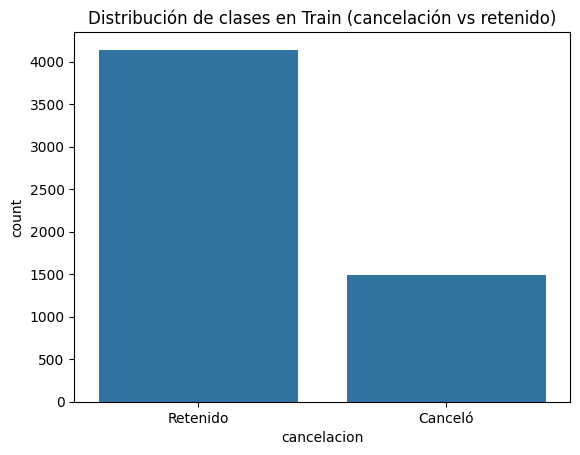

In [20]:
sns.countplot(x=y_train)
plt.title("Distribución de clases en Train (cancelación vs retenido)")
plt.show()


### 4️⃣ Inspeccionar variables procesadas

El `ColumnTransformer` convierte las categóricas en columnas one-hot, por eso podemos revisar los nombres así:

In [21]:
# Obtener nombres de columnas después del preprocesamiento
cat_features = preprocesador.transformers_[1][1].get_feature_names_out()
num_features = preprocesador.transformers_[0][2]
all_features = np.concatenate([num_features, cat_features])

print("Ejemplo de columnas procesadas:\n", all_features[:20])


Ejemplo de columnas procesadas:
 ['customer_tenure' 'cargo_mensual' 'id_cliente_0002-ORFBO'
 'id_cliente_0004-TLHLJ' 'id_cliente_0013-EXCHZ' 'id_cliente_0013-MHZWF'
 'id_cliente_0013-SMEOE' 'id_cliente_0014-BMAQU' 'id_cliente_0015-UOCOJ'
 'id_cliente_0016-QLJIS' 'id_cliente_0017-IUDMW' 'id_cliente_0019-EFAEP'
 'id_cliente_0020-INWCK' 'id_cliente_0021-IKXGC' 'id_cliente_0022-TCJCI'
 'id_cliente_0023-HGHWL' 'id_cliente_0023-UYUPN' 'id_cliente_0023-XUOPT'
 'id_cliente_0030-FNXPP' 'id_cliente_0031-PVLZI']


### 5️⃣ Guardar un DataFrame de entrenamiento listo

In [5]:
# Asegurar que los arrays no estén en formato sparse
if hasattr(X_train, "toarray"):
    X_train = X_train.toarray()
if hasattr(X_test, "toarray"):
    X_test = X_test.toarray()

# Obtener nombres de las features desde el preprocesador
num_features = preprocesador.transformers_[0][2]  # columnas numéricas
cat_encoder = preprocesador.transformers_[1][1]   # OneHotEncoder
cat_features = cat_encoder.get_feature_names_out(preprocesador.transformers_[1][2])

all_features = np.concatenate([num_features, cat_features])

# Crear DataFrames de entrenamiento y prueba
X_train_df = pd.DataFrame(X_train, columns=all_features)
X_test_df = pd.DataFrame(X_test, columns=all_features)

# Agregar la columna target
X_train_df["cancelacion"] = y_train.reset_index(drop=True)
X_test_df["cancelacion"] = y_test.reset_index(drop=True)

# Guardar los DataFrames listos
X_train_df.to_csv("data/processed/train_ready.csv", index=False)
X_test_df.to_csv("data/processed/test_ready.csv", index=False)

print("✅ DataFrames de entrenamiento y prueba guardados en data/processed/")
X_train_df.head()


✅ DataFrames de entrenamiento y prueba guardados en data/processed/


,customer_tenure,cargo_mensual,id_cliente_0002-ORFBO,id_cliente_0004-TLHLJ,id_cliente_0013-EXCHZ,id_cliente_0013-MHZWF,id_cliente_0013-SMEOE,id_cliente_0014-BMAQU,id_cliente_0015-UOCOJ,id_cliente_0016-QLJIS,...,cargo_total_995.35,cargo_total_996.45,cargo_total_996.85,cargo_total_996.95,cargo_total_997.65,cargo_total_997.75,cargo_total_999.45,cargo_total_999.8,cargo_total_999.9,cancelacion
0,-1.071436,-0.493018,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Retenido
1,0.231010,1.334258,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Canceló
2,1.289247,0.373234,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Retenido
3,0.882232,1.299341,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Canceló
4,-1.112137,-0.301810,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Retenido


In [6]:
# ================================
# 1. Verificar archivos .pkl
# ================================
salida_dir = "data/processed"

# Preprocesador
with open(os.path.join(salida_dir, "preprocesador.pkl"), "rb") as f:
    preprocesador_loaded = pickle.load(f)

print("✅ Preprocesador cargado desde preprocesador.pkl")
print("Tipo:", type(preprocesador_loaded))

# Datos procesados
with open(os.path.join(salida_dir, "datos_procesados.pkl"), "rb") as f:
    X_train_pkl, X_test_pkl, y_train_pkl, y_test_pkl = pickle.load(f)

print("\n✅ Datos procesados cargados desde datos_procesados.pkl")
print("Shapes:")
print("X_train:", X_train_pkl.shape)
print("X_test:", X_test_pkl.shape)
print("y_train:", y_train_pkl.shape)
print("y_test:", y_test_pkl.shape)

✅ Preprocesador cargado desde preprocesador.pkl
Tipo: <class 'sklearn.compose._column_transformer.ColumnTransformer'>

✅ Datos procesados cargados desde datos_procesados.pkl
Shapes:
X_train: (5634, 10963)
X_test: (1409, 10963)
y_train: (5634,)
y_test: (1409,)


In [7]:
# ================================
# 2. Verificar archivos CSV
# ================================
train_ready = pd.read_csv(os.path.join(salida_dir, "train_ready.csv"))
test_ready = pd.read_csv(os.path.join(salida_dir, "test_ready.csv"))

print("\n✅ DataFrames CSV cargados")
print("train_ready shape:", train_ready.shape)
print("test_ready shape:", test_ready.shape)

print("\nPrimeras filas de train_ready:")
display(train_ready.head(3))



✅ DataFrames CSV cargados
train_ready shape: (5634, 10964)
test_ready shape: (1409, 10964)

Primeras filas de train_ready:


,customer_tenure,cargo_mensual,id_cliente_0002-ORFBO,id_cliente_0004-TLHLJ,id_cliente_0013-EXCHZ,id_cliente_0013-MHZWF,id_cliente_0013-SMEOE,id_cliente_0014-BMAQU,id_cliente_0015-UOCOJ,id_cliente_0016-QLJIS,...,cargo_total_995.35,cargo_total_996.45,cargo_total_996.85,cargo_total_996.95,cargo_total_997.65,cargo_total_997.75,cargo_total_999.45,cargo_total_999.8,cargo_total_999.9,cancelacion
0,-1.071436,-0.493018,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Retenido
1,0.231010,1.334258,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Canceló
2,1.289247,0.373234,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Retenido


In [10]:
# === Generar y guardar nombres de variables después del preprocesamiento ===
import pickle
import os

FEATURE_NAMES_PATH = os.path.join("data", "processed", "feature_names.pkl")

# Obtenemos nombres de columnas después de OneHotEncoder y ColumnTransformer
categorical_features = preprocesador.transformers_[0][2]  # columnas categóricas originales
numeric_features = preprocesador.transformers_[1][2]      # columnas numéricas originales

# Nombres expandidos para variables categóricas (sin pasar input_features)
encoder = preprocesador.named_transformers_["cat"]
encoded_cols = encoder.get_feature_names_out()  

# Concatenamos categóricas transformadas + numéricas
feature_names = list(encoded_cols) + list(numeric_features)

# Guardamos en pickle
with open(FEATURE_NAMES_PATH, "wb") as f:
    pickle.dump(feature_names, f)

print(f"Se guardaron {len(feature_names)} variables en {FEATURE_NAMES_PATH}")
print("Ejemplo de variables:", feature_names[:10])


Se guardaron 10979 variables en data/processed/feature_names.pkl
Ejemplo de variables: ['id_cliente_0002-ORFBO', 'id_cliente_0004-TLHLJ', 'id_cliente_0013-EXCHZ', 'id_cliente_0013-MHZWF', 'id_cliente_0013-SMEOE', 'id_cliente_0014-BMAQU', 'id_cliente_0015-UOCOJ', 'id_cliente_0016-QLJIS', 'id_cliente_0017-IUDMW', 'id_cliente_0019-EFAEP']
